# Compositional Diffusion with Guided Search

This notebook implements Compositional Diffusion with Guided Search (CDGS), a structured
inference-time algorithm designed to identify coherent sequences of local modes that form valid
long-horizon global plans. CDGS integrates population-based search, iterative resampling for
information exchange across distant segments, and a pruning/ranking objective that suppresses
incoherent global plan candidates. The whole procedure runs inside a standard denoising diffusion
process, making CDGS a plug-and-play sampler for diverse domains. The goal of this notebook is to 
provide a clean and clear implementation of CDGS for the toy domain.

Notebook organization
- Setup and imports
- Model architectures and utilities (simple 2D U-Net used for experiments)
- Data loading and small synthetic dataset utilities
- CDGS implementation (compositional sampling, iterative resampling, local-feasibility based pruning)
- Visualization and analysis utilities
- Tests and example runs that reproduce figures used in the paper for toy-domain

In [ ]:
# [Optional] Colab setup
!git clone https://github.com/cdgsearch/getting_started_with_CDGS.git
%cd getting_started_with_CDGS
!uv pip install -r requirements.txt --system --no-progress

## 1. Import Libraries and Setup

First, let's import all necessary libraries and set up our environment.

In [1]:
import torch
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from data import MultiModalDataset 
# Diffusers imports: prefer scheduler-specific import paths to satisfy static checkers
# DDPMScheduler is provided under diffusers.schedulers.scheduling_ddpm in some versions.
try:
    from diffusers import DDPMScheduler
except Exception:
    from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from models import SimpleDiffusionModel, FlowMatchingModel
from utils import seed_everything, load_models
from samplers import CDGS

/Users/utkarshmishra/gsc_extension_project/notebook_release/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configure device between CUDA, MPS, and CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else "cpu"
)
print(f"Using device: {device}")

# Set seed for reproducibility
seed_everything(42)

Using device: mps


## 2. Dataset

Consider a synthetic 1-dimensional planning domain where a model starts at some initial value, and must hop from one mode to another to reach a goal. 

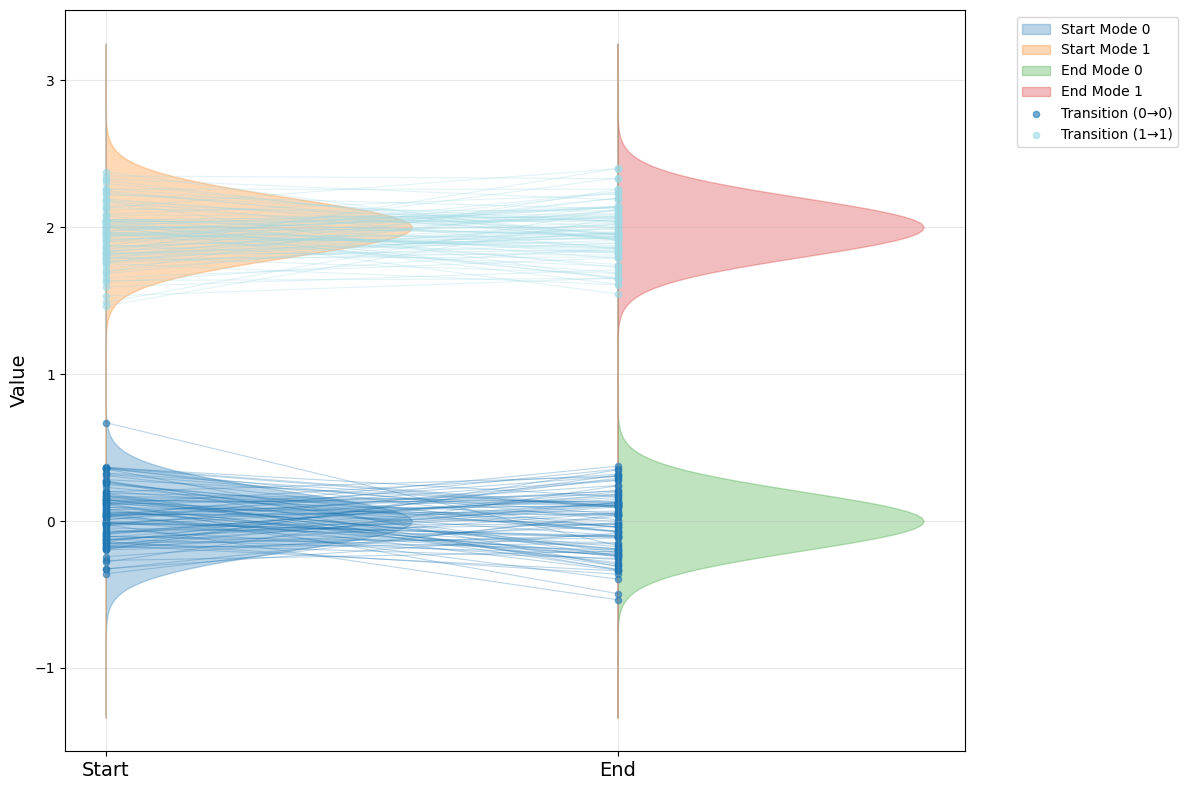

In [3]:
transition_matrix = np.array([
    [1, 0],  # Mode 0 of x1 can pair with mode 0,1 of x2
    [0, 1],
], dtype=bool)

dataset = MultiModalDataset(
    num_samples=5000,
    start_means=[0, 2],
    start_stds=[0.2, 0.2],
    end_means=[0, 2],
    end_stds=[0.2, 0.2],
    transition_matrix=transition_matrix
)

data_figure = dataset.plot_transitions(n=100)
plt.show()

## 3. Training of Diffusion or Flow-Based Models
For this toy domain, we use simple 2D U-Net models that can work with both diffusion and flow matching paradigms.

This section provides trains diffusion and flow matching models on our synthetic multimodal dataset. The code demonstrates how to set up the dataset, initialize the models, configure optimizers and schedulers, and periodically save checkpoints and generated samples for visualization. You can choose to train either a diffusion model or a flow matching model by running the corresponding cells below.

In [4]:
# Mode 0 of start can pair with mode 0,1 of end
transition_matrix = np.array([
    [1, 1],
], dtype=bool)

dataset = MultiModalDataset(
    num_samples=5000,
    start_means=[0],
    start_stds=[0.2],
    end_means=[-1, 1],
    end_stds=[0.2, 0.2],
    transition_matrix=transition_matrix
)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

Starting training loop on device:  mps


Loss: 0.2292, Acc: 0.976: 100%|██████████| 200/200 [01:32<00:00,  2.16it/s]


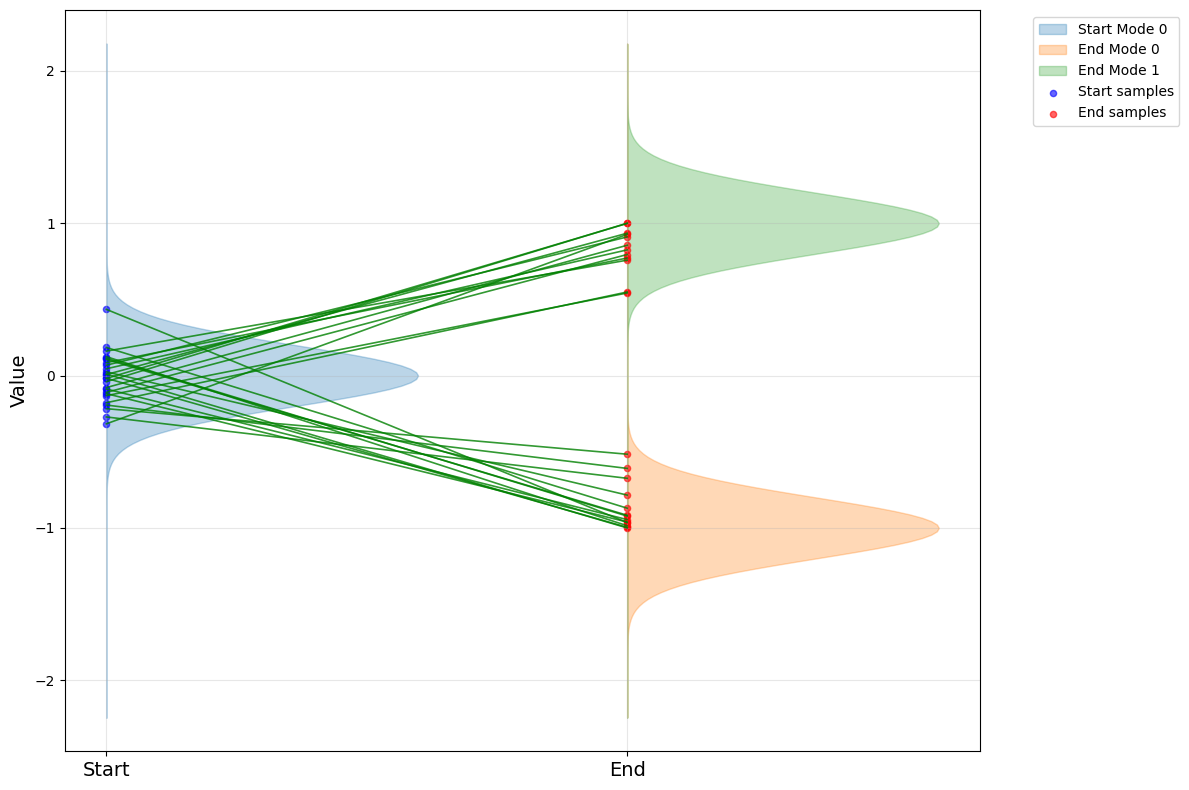

In [12]:
model = SimpleDiffusionModel().to(device)
scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear"
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 200
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("training", exist_ok=True)

print("Starting training loop on device: ", device)

accuracy = 0.0
pbar = tqdm(range(num_epochs), desc="Loss: 0.0")
for epoch in pbar:
    for batch in tqdm(dataloader, total=len(dataloader), leave=False):
        optimizer.zero_grad()
        batch = batch.to(device)
        loss = model.training_step(batch, scheduler)  # batch[0] contains the data points
        loss.backward()
        optimizer.step()
    
    # save model
    if (epoch % 50 == 0 and epoch > 0) or epoch == num_epochs - 1:
        torch.save(model.state_dict(), "checkpoints/simple_diffusion_model.pth")

        # Sampling
        samples = model.sample(
            batch_size=1000,
            noise_scheduler=scheduler,
            device=device,
            num_inference_steps=50
        )   
        accuracy = dataset.compute_accuracy(samples)
    pbar.set_description(f"Loss: {loss.item():.4f}, Acc: {accuracy:.3f}")

samples = model.sample(
    batch_size=200,
    noise_scheduler=scheduler,
    device=device,
    num_inference_steps=50
).cpu().numpy()
fig = dataset.plot_transitions(samples, annotate_valid=True)

Starting training loop on device:  mps


Loss: 0.9775, Acc: 0.979: 100%|██████████| 200/200 [02:19<00:00,  1.44it/s]


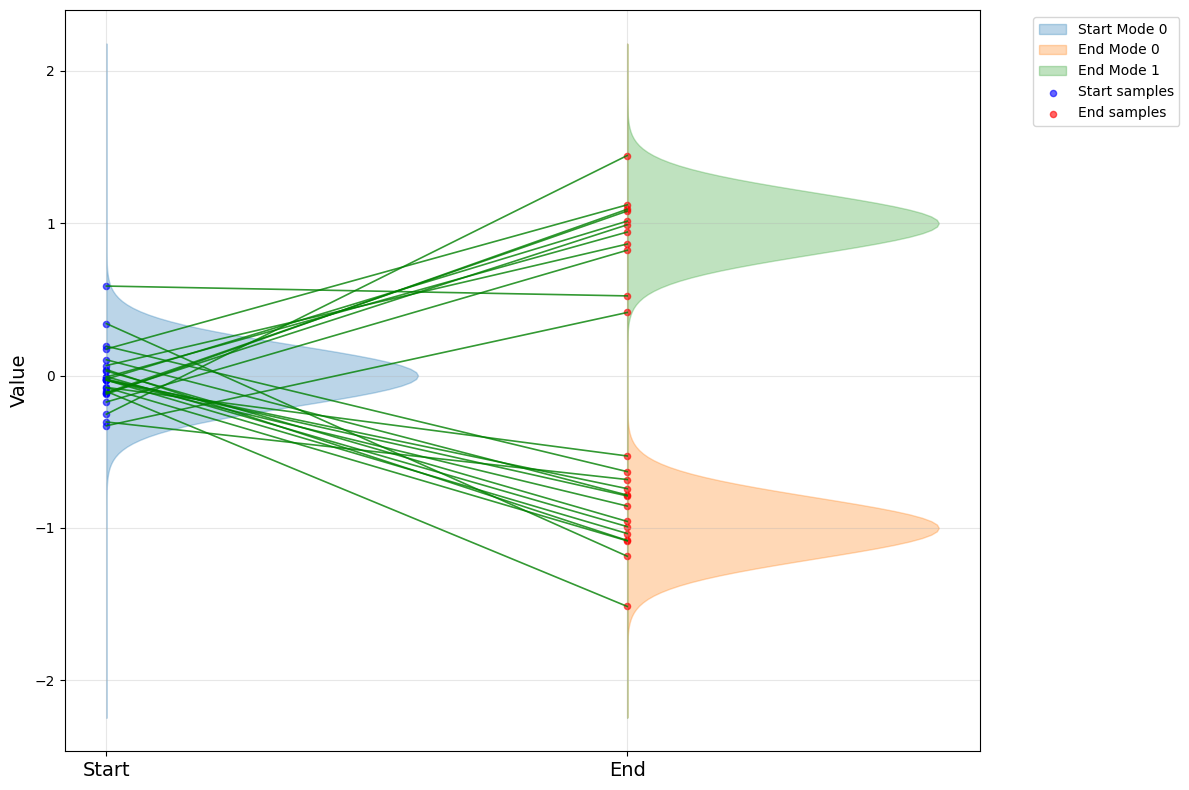

In [13]:
model = FlowMatchingModel().to(device)
scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear"
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 200
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("training", exist_ok=True)

print("Starting training loop on device: ", device)

accuracy = 0.0
pbar = tqdm(range(num_epochs), desc="Loss: 0.0")
for epoch in pbar:
    for batch in tqdm(dataloader, total=len(dataloader), leave=False):
        optimizer.zero_grad()
        batch = batch.to(device)
        loss = model.training_step(batch)  # batch[0] contains the data points
        loss.backward()
        optimizer.step()
    
    # save model
    if (epoch % 50 == 0 and epoch > 0) or epoch == num_epochs - 1:
        torch.save(model.state_dict(), "checkpoints/simple_flow_model.pth")

        # Sampling
        samples = model.sample(
            batch_size=1000,
            device=device,
            num_inference_steps=100
        )
        accuracy = dataset.compute_accuracy(samples)
    pbar.set_description(f"Loss: {loss.item():.4f}, Acc: {accuracy:.3f}")

samples = model.sample(
    batch_size=200,
    device=device,
    num_inference_steps=100
).cpu().numpy()
fig = dataset.plot_transitions(samples, annotate_valid=True)

## 4. Data Loading and Preprocessing

Now let's load our pre-trained model checkpoints. We have three types of models:
- **Model 1**: Edge model (first distribution)
- **Model 2**: Bridge model (intermediate distributions) 
- **Model 3**: Edge model (final distribution)

In [5]:
num_samples = 1000  # Adjust as needed
seed = 42  # For reproducibility

start_dataset = MultiModalDataset(
    num_samples=num_samples,
    start_means=[0.0],
    start_stds=[0.2],
    end_means=[0.75, -0.75],
    end_stds=[0.1, 0.1],
    transition_matrix=np.array([
        [1, 1] 
    ], dtype=bool),
    seed=seed
)

bridge_dataset = MultiModalDataset(
    num_samples=num_samples,
    start_means=[0.75, -0.75],
    start_stds=[0.1, 0.1],
    end_means=[0.75, -0.75],
    end_stds=[0.1, 0.1],
    transition_matrix=np.array([
        [1, 0],
        [0, 1]
    ], dtype=bool),
    seed=seed
)

end_dataset = MultiModalDataset(
    num_samples=num_samples,
    start_means=[0.75, -0.75],
    start_stds=[0.1, 0.1],
    end_means=[0.0],
    end_stds=[0.2],
    transition_matrix=np.array([
        [1],
        [1]
    ], dtype=bool),
    seed=seed
)

In [6]:
# Test diffusion model loading
num_bridges = 4
diffusion_model_paths = {
    "start": "./pretrained_checkpoints/simple_diffusion_model_start.pth",
    "bridge": "./pretrained_checkpoints/simple_diffusion_model_bridge.pth",
    "end": "./pretrained_checkpoints/simple_diffusion_model_end.pth"
}
models = load_models(device, diffusion_model_paths, SimpleDiffusionModel, num_bridges)

# Test flow matching model loading
num_bridges = 4
flow_model_paths = {
    "start": "./pretrained_checkpoints/flow_matching_model_start.pth",
    "bridge": "./pretrained_checkpoints/flow_matching_model_bridge.pth",
    "end": "./pretrained_checkpoints/flow_matching_model_end.pth"
}
models = load_models(device, flow_model_paths, FlowMatchingModel, num_bridges)

Successfully loaded 6 models
Successfully loaded 6 models


 
## 5. CDGS Sampler Class

This section introduces the unified CDGS (Compositional Diffusion with Guided Search) sampler class. The class implements compositional inference-time algorithms for generating coherent long-horizon samples by combining multiple local models.

The `CDGS` class is highly configurable through parameters that control:

- **Basic Compositional Sampling** (`num_resampling_steps=1`, `enable_pruning=False`): Standard compositional prediction without additional techniques
- **Iterative Resampling** (`num_resampling_steps>1`): Re-denoise from the same timestep multiple times to improve compositional alignment  
- **Inversion Pruning** (`enable_pruning=True`): Select samples with smoother DDIM inversion paths, indicating higher quality local plans

This unified design makes it easy to experiment with different levels of compositional guidance by simply adjusting parameters. The sampler is compatible with both diffusion and flow-matching models (flow support is scaffolded for future implementation), and uses the loaded model checkpoints and scheduler defined above. Example usage and visualization utilities are provided in the following cells.

Successfully loaded 7 models
Created 7 views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8)]
Total latent dimension: 8
✅ CDGS initialized:
  Model type: <class 'models.SimpleDiffusionModel'>
  Number of models: 7
  Views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8)]
  Latent dimension: 8
  Resampling steps: 0
  Pruning: disabled


Sampling: 100%|██████████| 100/100 [00:00<00:00, 155980.07it/s]

Generated samples shape (diffusion): torch.Size([1000, 8])


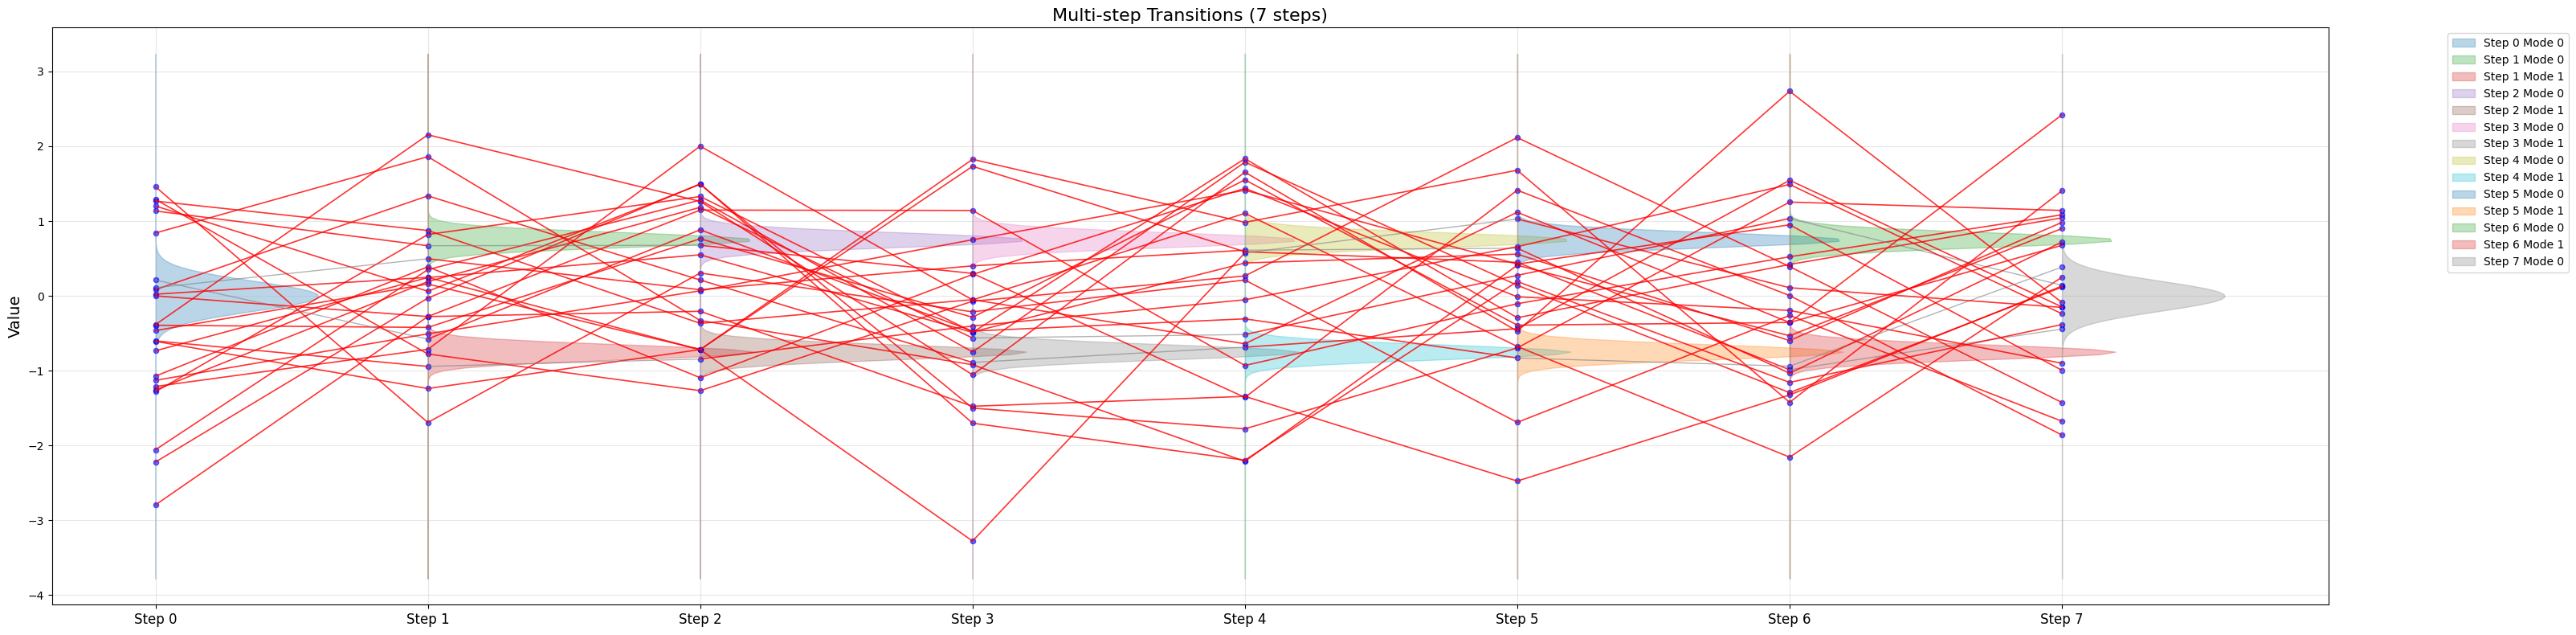

In [9]:
num_samples_to_generate = 1000
num_inference_steps = 100
num_bridges = 5

sampler = CDGS(
    model_paths=diffusion_model_paths,
    device=str(device),
    model_type=SimpleDiffusionModel,
    num_bridges=num_bridges,
    num_resampling_steps=0,
    enable_pruning=False
)

samples = sampler.sample(batch_size=num_samples_to_generate, num_inference_steps=num_inference_steps)
print("Generated samples shape (diffusion):", samples.shape)
fig = MultiModalDataset.plot_multi_step_transitions([start_dataset] + [bridge_dataset]*num_bridges + [end_dataset], samples.cpu().numpy(), annotate_valid=True)

Successfully loaded 7 models
Created 7 views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8)]
Total latent dimension: 8
✅ CDGS initialized:
  Model type: <class 'models.SimpleDiffusionModel'>
  Number of models: 7
  Views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8)]
  Latent dimension: 8
  Resampling steps: 5
  Pruning: disabled


Sampling: 100%|██████████| 100/100 [00:21<00:00,  4.71it/s]


Generated samples shape (diffusion): torch.Size([1000, 8])


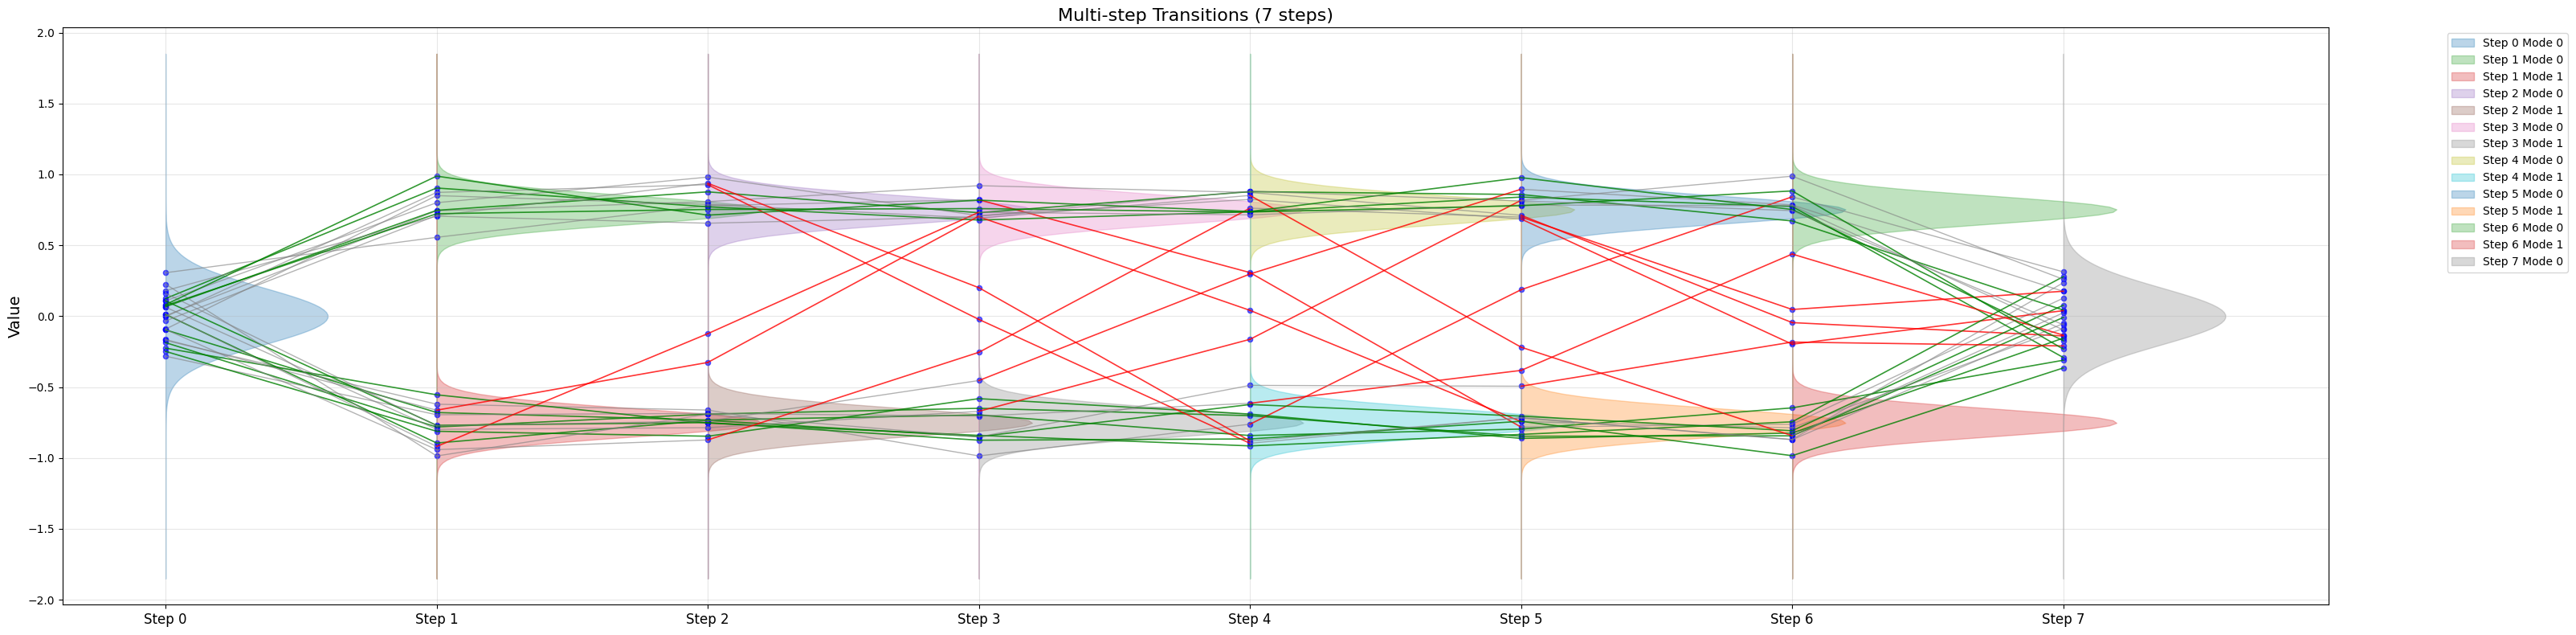

In [10]:
num_samples_to_generate = 1000
num_inference_steps = 100
num_bridges = 5

sampler = CDGS(
    model_paths=diffusion_model_paths,
    device=str(device),
    model_type=SimpleDiffusionModel,
    num_bridges=num_bridges,
    num_resampling_steps=5,
    enable_pruning=False
)

samples = sampler.sample(batch_size=num_samples_to_generate, num_inference_steps=num_inference_steps)
print("Generated samples shape (diffusion):", samples.shape)
fig = MultiModalDataset.plot_multi_step_transitions([start_dataset] + [bridge_dataset]*num_bridges + [end_dataset], samples.cpu().numpy(), annotate_valid=True)

Successfully loaded 7 models
Created 7 views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8)]
Total latent dimension: 8
✅ CDGS initialized:
  Model type: <class 'models.SimpleDiffusionModel'>
  Number of models: 7
  Views: [(0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 7), (6, 8)]
  Latent dimension: 8
  Resampling steps: 10
  Pruning: enabled
    - Pruning window: 0.0 to 1.0
    - Top-K fraction: 0.2


Sampling: 100%|██████████| 100/100 [01:04<00:00,  1.54it/s]


Generated samples shape (diffusion): torch.Size([1000, 8])


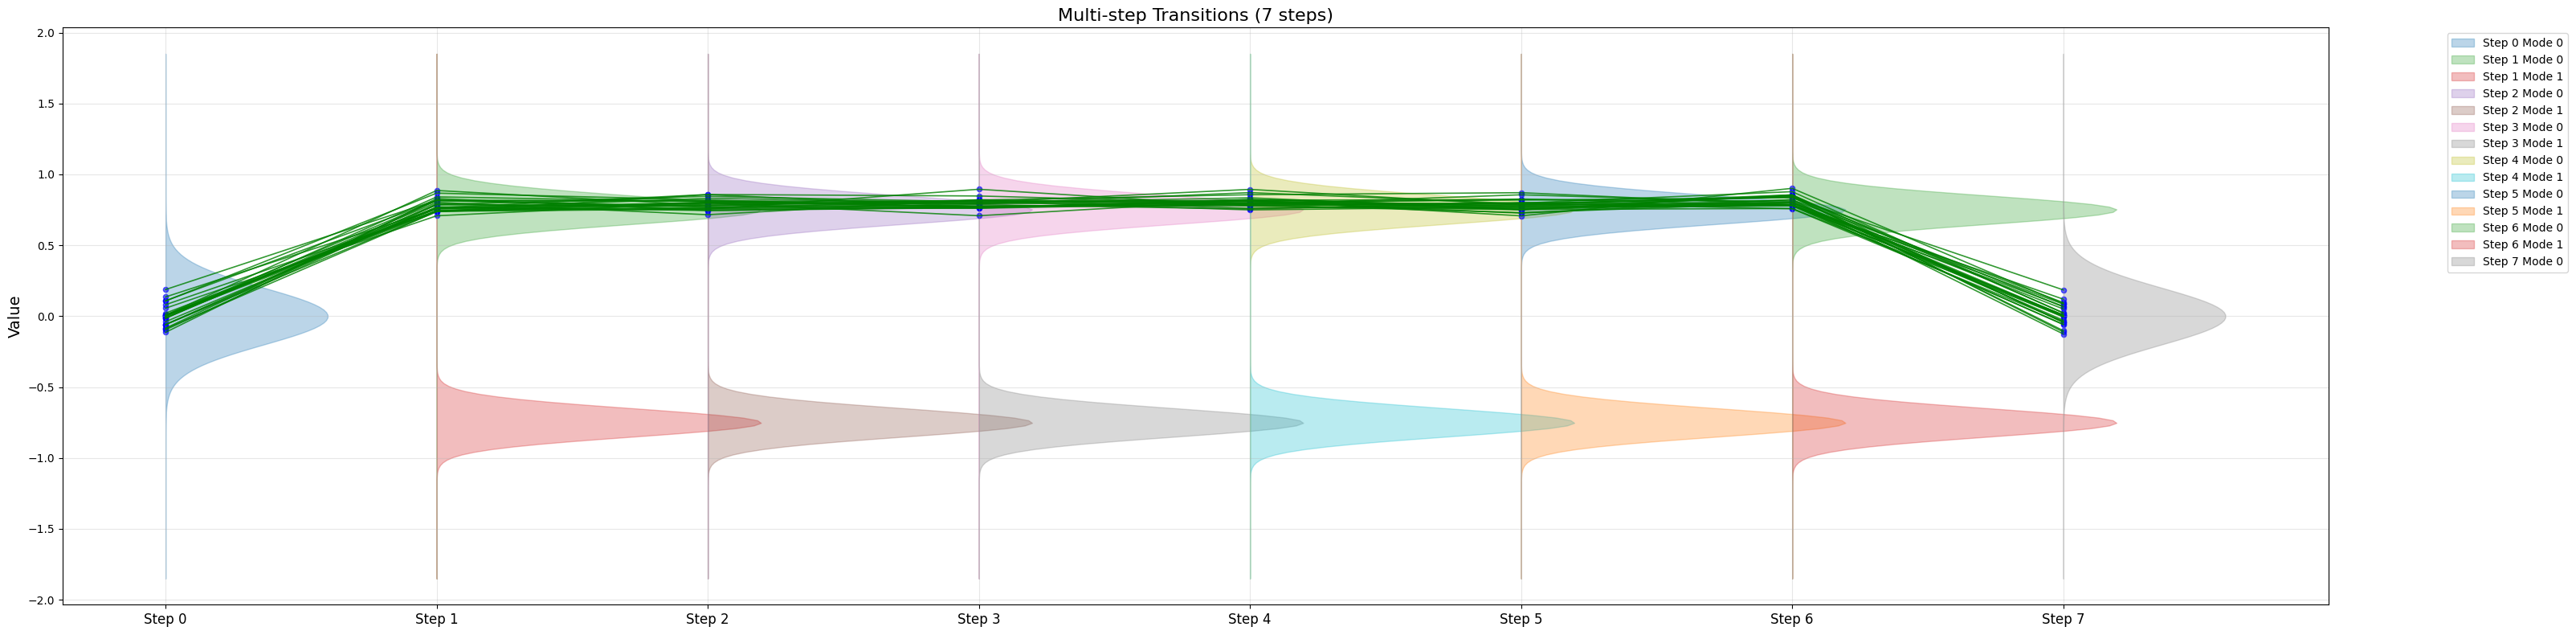

In [11]:
num_samples_to_generate = 1000
num_inference_steps = 100
num_bridges = 5

sampler = CDGS(
    model_paths=diffusion_model_paths,
    device=str(device),
    model_type=SimpleDiffusionModel,
    num_bridges=num_bridges,
    num_resampling_steps=10,
    pruning_start=0.0,
    pruning_end=1.0,
    pruning_top_K=0.2,
    enable_pruning=True
)

samples = sampler.sample(batch_size=num_samples_to_generate, num_inference_steps=num_inference_steps)
print("Generated samples shape (diffusion):", samples.shape)
fig = MultiModalDataset.plot_multi_step_transitions([start_dataset] + [bridge_dataset]*num_bridges + [end_dataset], samples.cpu().numpy(), annotate_valid=True)